In [79]:
import numpy as np
import pandas as pd

import re
from tqdm import tqdm
import nltk
nltk.data.path.append("/Users/nikitadolgov/nltk_data")  # твой путь к папке nltk_data

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from nltk.stem import SnowballStemmer

In [80]:
# для установки всех необходимых пакетов nltk

'''import nltk
nltk.download()'''

'import nltk\nnltk.download()'

## Загрузка датасета

In [81]:
import os

full_data_path = os.path.join("/Users/nikitadolgov/DataBases/text_emotions/Text_Emotion.csv")

In [82]:
full_df = pd.read_csv(full_data_path)
full_df

,text,emotion
0,carefully word blog posts amount criticism hea...,☹️
1,cannot remember little mermaid feeling carefre...,🙂
2,not feeling super well turns cold knocked next...,🙂
3,feel honored part group amazing talents,🙂
4,think helping also began feel pretty lonely lo...,☹️
...,...,...
282817,feel honored motivated share world life changi...,🙂
282818,feel like gloaty really delighted,🙂
282819,feel little energetic one day next several day...,🙂
282820,feel work experience fell although fantastic o...,🙂


In [83]:
full_df[full_df.loc[:, ['emotion']] == '☹️'] = 0
full_df[full_df.loc[:, ['emotion']] == '🙂'] = 1
full_df

,text,emotion
0,carefully word blog posts amount criticism hea...,0
1,cannot remember little mermaid feeling carefre...,1
2,not feeling super well turns cold knocked next...,1
3,feel honored part group amazing talents,1
4,think helping also began feel pretty lonely lo...,0
...,...,...
282817,feel honored motivated share world life changi...,1
282818,feel like gloaty really delighted,1
282819,feel little energetic one day next several day...,1
282820,feel work experience fell although fantastic o...,1


In [84]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282822 entries, 0 to 282821
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     282822 non-null  object
 1   emotion  282822 non-null  object
dtypes: object(2)
memory usage: 4.3+ MB


In [85]:
full_df.emotion = full_df.emotion.astype('Int8')
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 282822 entries, 0 to 282821
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   text     282822 non-null  object
 1   emotion  282822 non-null  Int8  
dtypes: Int8(1), object(1)
memory usage: 2.7+ MB


In [86]:
full_df.isna().sum()  # нет Nan значений, что было показано при выводе info

text       0
emotion    0
dtype: int64

In [87]:
# примеры текста отрицательных эмоций
for true_value in full_df[full_df.emotion == 0].sample(5)['text']:
    print(true_value)

feel like punished something even
sent article afternoon feeling sort exhausted mania
feeling homesick somewhere got wanderlust
feel humiliated young body started respond
feel times may no warning may suddenly feel awful


In [88]:
# примеры текста положительных эмоций
for true_value in full_df[full_df.emotion == 1].sample(5)['text'].head(5):
    print(true_value)

feel terrific told lie
want break finally feel free not bound experiment created
feel education system putting much focus assessment planning etc etc less time focus supporting children helping develop people
believe every bride groom walk aisle feeling divine
teach vocabulary school sometimes students repeat word aloud feels good tongue


Предложения не похожи на написанные человеком. Они не являются полноценными. Слова идут обрывками и полный смысл предложения не понятен.

### Гипотеза: текст уже был предобработан

In [89]:
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

def remove_multiple_spaces(text):
  """удаление специальных символов"""
  return re.sub(r'\s+', ' ', text, flags=re.I)

In [96]:
from nltk.tokenize import TreebankWordTokenizer
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

# Настройка
english_stop_words = stopwords.words('english')
snowball = SnowballStemmer(language='english')
tokenizer = TreebankWordTokenizer()  # токенизатор слов напрямую

def tokenize_sentence(sentence: str, remove_stop_words: bool = True):
    # базовая очистка
    prep_text = remove_multiple_spaces(remove_numbers(remove_punctuation(sentence.lower())))

    # токенизация без punkt_tab
    tokens = tokenizer.tokenize(prep_text)

    # удаление стоп-слов
    if remove_stop_words:
        tokens = [t for t in tokens if t not in english_stop_words]

    # стемминг
    tokens = [snowball.stem(t) for t in tokens]

    return tokens

In [97]:
for true_value in full_df[full_df.emotion == 1].sample(10)['text']:
    print(len(true_value.split()), len(tokenize_sentence(true_value)))

4 4
10 10
15 14
11 11
15 15
5 5
18 18
5 5
5 5
7 7


до обработки

In [98]:
text_length = full_df.text.apply(len).to_list()  # длины строк с текстом
text_word_amout = []  # количество слов в тексте (важно, тк при обработке происходит еще и стемминг)
for i in full_df.text:
    text_word_amout += [len(i.split())]

обработка

In [99]:
english_stopwords = stopwords.words("english")

In [100]:
prep_texts = []
for t in tqdm(full_df.text):
    prep_texts.append(' '.join(tokenize_sentence(t)))

100%|██████████| 282822/282822 [00:10<00:00, 26093.30it/s]


In [101]:
full_df['prep_text'] = prep_texts
full_df

,text,emotion,prep_text
0,carefully word blog posts amount criticism hea...,0,care word blog post amount critic hear place c...
1,cannot remember little mermaid feeling carefre...,1,rememb littl mermaid feel carefre beauti life ...
2,not feeling super well turns cold knocked next...,1,feel super well turn cold knock next three wee...
3,feel honored part group amazing talents,1,feel honor part group amaz talent
4,think helping also began feel pretty lonely lo...,0,think help also began feel pretti lone lot peo...
...,...,...,...
282817,feel honored motivated share world life changi...,1,feel honor motiv share world life chang gift a...
282818,feel like gloaty really delighted,1,feel like gloati realli delight
282819,feel little energetic one day next several day...,1,feel littl energet one day next sever day hard...
282820,feel work experience fell although fantastic o...,1,feel work experi fell although fantast opportu...


In [102]:
text_length2 = full_df.prep_text.apply(len).to_list()
text_word_amout2 = []  # количество слов в тексте (важно, тк при обработке происходит еще и стемминг)
for i in full_df.text:
    text_word_amout2 += [len(i.split())]

In [103]:
mean_len_diff = np.mean([abs(text_length2[i] - text_length[i]) for i in range(len(text_length))])
mean_amount_diff = np.mean([abs(text_word_amout2[i] - text_word_amout[i]) for i in range(len(text_word_amout))])

In [104]:
print(f'средняя разница длин строк до и после обработки: {mean_len_diff}')
print(f'средняя разница количества слов в строках до и после обработки: {mean_amount_diff}')

средняя разница длин строк до и после обработки: 8.757479969733613
средняя разница количества слов в строках до и после обработки: 0.0


Вывод: текст скорее всего уже был обработан по двум причинам: средняя разница количества слов в строках до и после обработки равна 0, предложения являются несвязными. Но обработка была другая, возможно, с использованием других библиотек. Обработка была неполной. К примеру, не был сделан стемминг и лемматизация

Основываясь на том, что гипотеза не была точно подтверждена или опровергнута, будут созданы несколько вариантов датасета: 
1) удаление специальных символов, чисел и пунктуации, стоп слов
2) удаление специальных символов, чисел и пунктуации, стоп слов + стемминг

В датасете не будет изначально проведена лемматизация, потому что это очень времязатратный процесс. Выдвигается новая гипотеза: отсутствие лемматизации не скажется на качестве модели.

## Создание датасета с различными степенями обработки данных

полностью обработанный датасет уже создан, просто переименовываем столбец с ним

In [105]:
full_df.rename(columns={'prep_text': 'full_prep_text'}, inplace=True)

In [110]:

tokenizer = TreebankWordTokenizer()

def tokenize_sentence(sentence: str, remove_stop_words: bool = True):
    # Очистка текста
    prep_text = remove_multiple_spaces(remove_numbers(remove_punctuation(sentence.lower())))

    # Токенизация без проблем с punkt_tab
    tokens = tokenizer.tokenize(prep_text)

    # Удаление стоп-слов
    if remove_stop_words:
        tokens = [i for i in tokens if i not in english_stop_words]

    return tokens


In [111]:
prep_text = [' '.join(tokenize_sentence(text)) for text in full_df.text]

In [112]:
full_df['no_stem_text'] = prep_text

In [113]:
full_df

,text,emotion,full_prep_text,no_stem_text
0,carefully word blog posts amount criticism hea...,0,care word blog post amount critic hear place c...,carefully word blog posts amount criticism hea...
1,cannot remember little mermaid feeling carefre...,1,rememb littl mermaid feel carefre beauti life ...,remember little mermaid feeling carefree beaut...
2,not feeling super well turns cold knocked next...,1,feel super well turn cold knock next three wee...,feeling super well turns cold knocked next thr...
3,feel honored part group amazing talents,1,feel honor part group amaz talent,feel honored part group amazing talents
4,think helping also began feel pretty lonely lo...,0,think help also began feel pretti lone lot peo...,think helping also began feel pretty lonely lo...
...,...,...,...,...
282817,feel honored motivated share world life changi...,1,feel honor motiv share world life chang gift a...,feel honored motivated share world life changi...
282818,feel like gloaty really delighted,1,feel like gloati realli delight,feel like gloaty really delighted
282819,feel little energetic one day next several day...,1,feel littl energet one day next sever day hard...,feel little energetic one day next several day...
282820,feel work experience fell although fantastic o...,1,feel work experi fell although fantast opportu...,feel work experience fell although fantastic o...


In [114]:
full_df.dropna(inplace=True)

## Промежуточное сохранение
чтобы каждый раз не делать обработку, а просто загружать готовый датасет

In [117]:
full_df.to_csv('/Users/nikitadolgov/DataBases/prepared_datasets/full_dataset_emotions_text.csv', index=False)

In [120]:
full_df = pd.read_csv('/Users/nikitadolgov/DataBases/prepared_datasets/full_dataset_emotions_text.csv')
full_df

,text,emotion,full_prep_text,no_stem_text
0,carefully word blog posts amount criticism hea...,0,care word blog post amount critic hear place c...,carefully word blog posts amount criticism hea...
1,cannot remember little mermaid feeling carefre...,1,rememb littl mermaid feel carefre beauti life ...,remember little mermaid feeling carefree beaut...
2,not feeling super well turns cold knocked next...,1,feel super well turn cold knock next three wee...,feeling super well turns cold knocked next thr...
3,feel honored part group amazing talents,1,feel honor part group amaz talent,feel honored part group amazing talents
4,think helping also began feel pretty lonely lo...,0,think help also began feel pretti lone lot peo...,think helping also began feel pretty lonely lo...
...,...,...,...,...
282817,feel honored motivated share world life changi...,1,feel honor motiv share world life chang gift a...,feel honored motivated share world life changi...
282818,feel like gloaty really delighted,1,feel like gloati realli delight,feel like gloaty really delighted
282819,feel little energetic one day next several day...,1,feel littl energet one day next sever day hard...,feel little energetic one day next several day...
282820,feel work experience fell although fantastic o...,1,feel work experi fell although fantast opportu...,feel work experience fell although fantastic o...


## Распределение длины текста

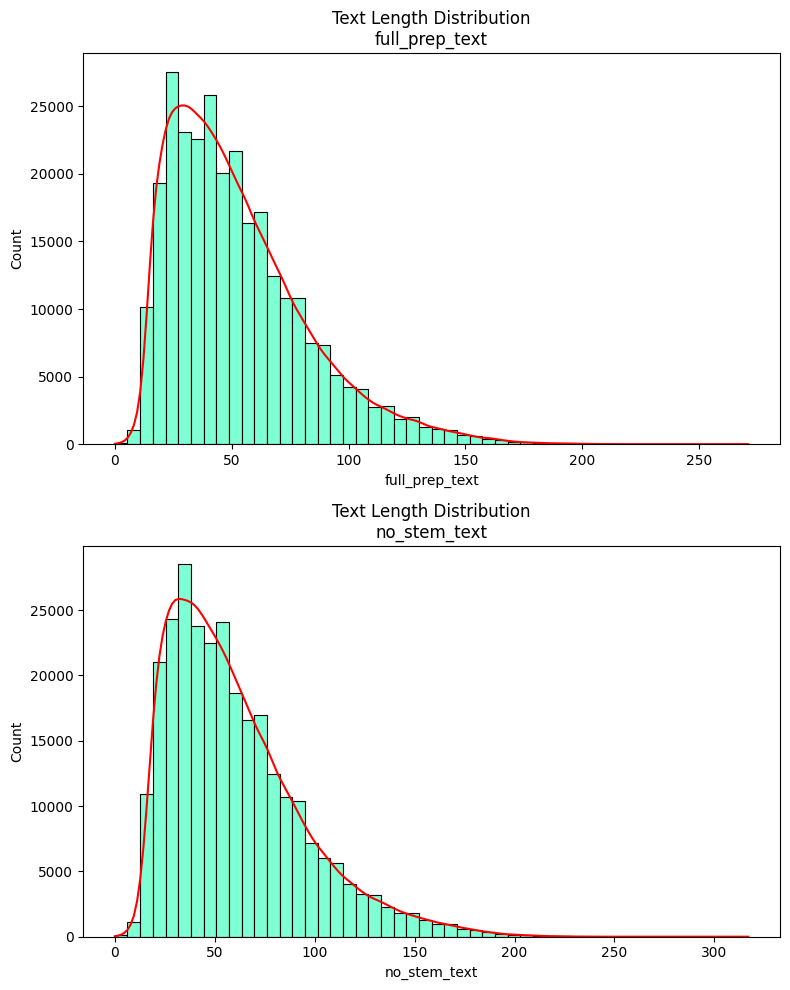

In [130]:
import seaborn as sns
import matplotlib.pyplot as plt

columns = full_df.columns.to_numpy()[2:]
fig, axes = plt.subplots(nrows=len(columns), figsize=(8, 5*len(columns)))

for i, (column, ax) in enumerate(zip(columns, axes)):
    text_length = full_df[column].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)
    sns.histplot(text_length, bins=50, color='red', kde=True, facecolor='aquamarine', ax=ax)
    ax.set_title(f'Text Length Distribution\n{column}')

plt.tight_layout()
plt.show()

Как показано на графике, распределение длины текста практически не отличается. Это еще раз доказывает предобработанное начало датасета

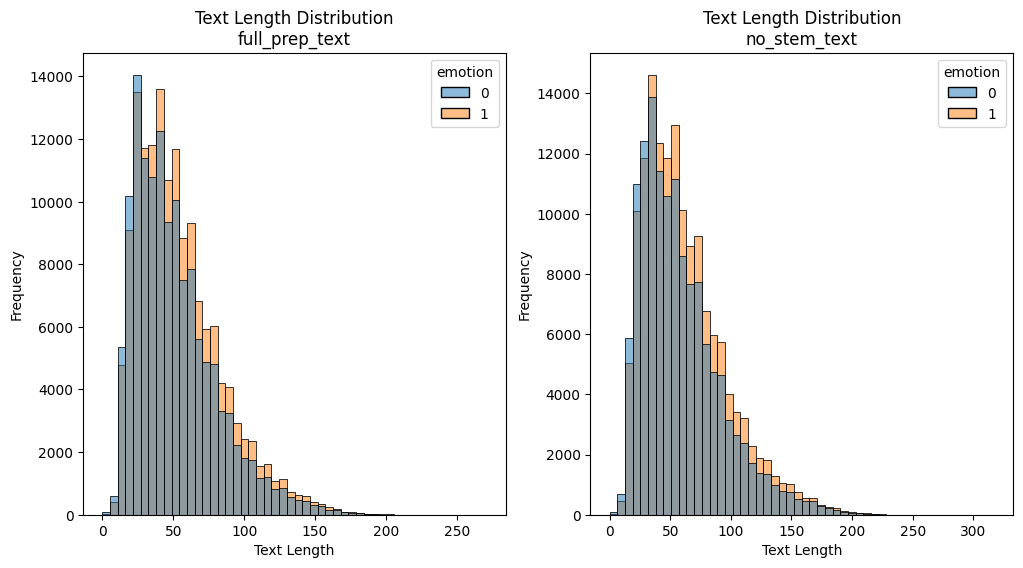

In [134]:
f, axes = plt.subplots(1, 2)
f.set_figheight(6)
f.set_figwidth(12)

df = full_df.copy()

columns = full_df.columns.to_numpy()[2:]
for i, (column, ax) in enumerate(zip(columns, axes)):
    df['length'] = df[column].apply(lambda x: len(str(x)) if pd.notnull(x) else 0)

    sns.histplot(
        data=df,
        ax=ax,
        x='length',
        hue='emotion',
        multiple='layer',
        bins=50
    )

    ax.set_title(f'Text Length Distribution\n{column}')
    ax.set_xlabel('Text Length')
    ax.set_ylabel('Frequency')

Данные графики показывают, что в датасете у эмоций одинаковое распределение длин текста, что свидетельствует об отсутствии значимой зависимости между длиной текста и эмоцией

## WordCloud

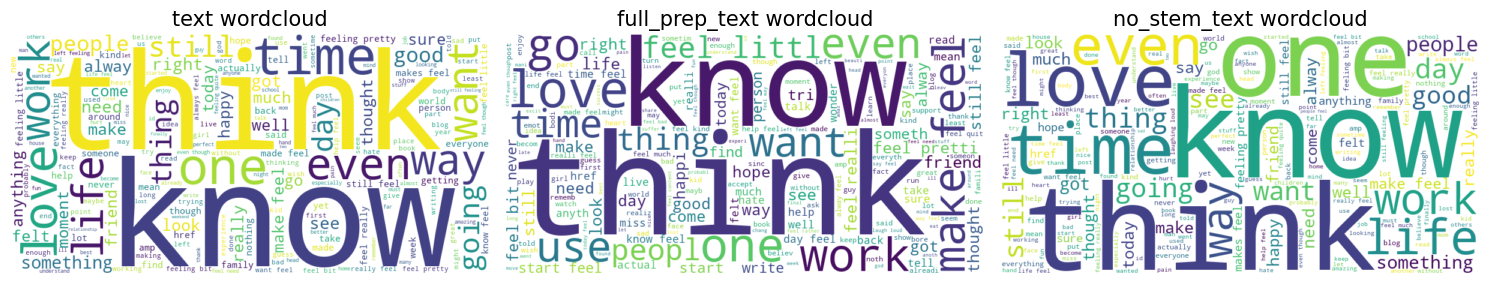

In [137]:
from wordcloud import WordCloud

f, axes = plt.subplots(1, 3)
f.set_figheight(10)
f.set_figwidth(15)

columns = full_df.columns.to_numpy()[[0, 2, 3]]
for i, (column, ax) in enumerate(zip(columns, axes)):
    # приводим всё к строкам и убираем NaN
    result = set(str(x) for x in full_df[column] if pd.notnull(x))
    result_text = ' '.join(result)

    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(result_text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{column} wordcloud', fontsize=15)

plt.tight_layout()
plt.show()

## Диаграмма распределения классов

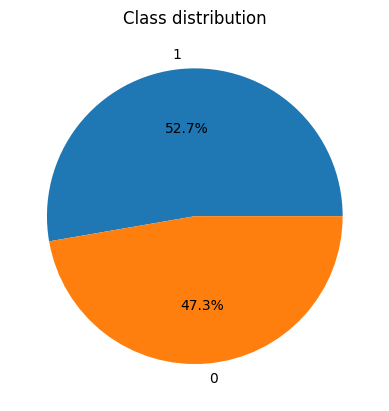

In [138]:
full_df.emotion.value_counts().plot(kind='pie', title='Class distribution', autopct='%1.1f%%')
plt.axis('off')
plt.show()

Распределение классов сбалансировано, следовательно, не нужно делать oversampling/undersampling